In [1]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms as transforms
from matplotlib.legend_handler import HandlerTuple
from torchvision.io import read_image

In [2]:
nerv_save_dir = '../plotting_source_data/NeRV/C-INRs_perhaps_care_about_objects'
mlp_save_dir = '../plotting_source_data/MLP/C-INRs_perhaps_care_about_objects'

nerv_per_vid_kernel_contribs_across_time_dict = pickle.load(open(f'{nerv_save_dir}/per_vid_kernel_contribs_across_time.pkl', 'rb'))
mlp_per_vid_neuron_to_inst_contrib_dict = pickle.load(open(f'{mlp_save_dir}/per_vid_neuron_to_inst_contrib_dict.pkl', 'rb'))

# Flow stuff
nerv_per_vid_optical_flow_dict = pickle.load(open(f'{nerv_save_dir}/per_vid_optical_flow_dict.pkl', 'rb'))

In [13]:
rgb_img_paths = {
    "0005": "../data/cityscapes_vps/val/img_all/frankfurt_000000_001736_leftImg8bit.png",
    "0175": "../data/cityscapes_vps/val/img_all/frankfurt_000001_049683_leftImg8bit.png",
    "12_n-ytHkMceew": "../data/VIPSeg-Dataset/VIPSeg/VIPSeg_720P/images/12_n-ytHkMceew/00002537.jpg",
    "26_cblDl5vCZnw": "../data/VIPSeg-Dataset/VIPSeg/VIPSeg_720P/images/26_cblDl5vCZnw/00000976.jpg"
}

vipseg_vids = ["12_n-ytHkMceew", "26_cblDl5vCZnw"]

selected_objects = {
    "0005": ["car", "person", "building", "sky", "traffic light"],
    "26_cblDl5vCZnw": ["person", "ceiling", "wall", "bench", "floor"]
}

In [4]:
custom_colors = [
    '#1f77b4', '#2ca02c', '#d62728', '#e377c2', '#ff7f0e',
    '#843c39', '#7b4173', '#5254a3', '#fdc7c7', '#637939',
    '#02a3a3', '#17becf', '#b1c2b3', '#ff9896', '#7f7f7f',
    '#f5c651', '#bcbd22', '#04c2b2'
]

In [60]:
def plot_mlp(
    ax, selected_objects, object_to_color_map, markers, mlp_num_neuron_samples_per_layer, obj_to_obj_name_idx, mlp_instance_names, mlp_num_instances_per_obj, mlp_inst_neuron_contribs
):
    # In 1-th column, plot the MLP kernels-to-instances
    x = np.arange(mlp_num_neuron_samples_per_layer * 3)
    x_offsets = np.linspace(-0.25, 0.25, len(obj_to_obj_name_idx.keys()))
    
    leading_obj = '_'.join(mlp_instance_names[0].split('_')[0:-1])
    marker_idx = -1
    
    for inst_num, inst_name in enumerate(mlp_instance_names):
        
        # Filter out the instances to plot
        if ('_'.join(inst_name.split('_')[0:-1]) not in selected_objects):
            continue
        
        # reset marker index for each new object
        if('_'.join(inst_name.split('_')[0:-1]) == leading_obj):
            marker_idx += 1
        else:
            marker_idx = 0
            leading_obj = '_'.join(inst_name.split('_')[0:-1])
        
        if marker_idx < mlp_num_instances_per_obj:
            data_with_nones = np.where(mlp_inst_neuron_contribs[inst_num, :] == 0.0, None, mlp_inst_neuron_contribs[inst_num, :])
            offset_for_obj = x_offsets[list(obj_to_obj_name_idx.keys()).index(leading_obj)]
            label = inst_name.replace(' ', '_')
            label = label.replace('vegitation', 'vegetation')
            ax.plot(x + offset_for_obj, data_with_nones, marker=markers[marker_idx], markersize=7, linestyle='None', label=label, color=object_to_color_map[leading_obj])

    # Add vertical lines between the 3rd and 4th x-ticks and between the 6th and 7th x-ticks
    ax.axvline(x=2.5, linestyle='--', color='gray', alpha=0.4, linewidth=1)
    ax.axvline(x=5.5, linestyle='--', color='gray', alpha=0.4, linewidth=1)
    
    ax.set_xticks(x)
    ax.set_xticklabels([' ' for range in range(len(x))])
    
    return ax

In [61]:
def plot_nerv_head(
    ax1, ax2, selected_objects, all_variables_for_video, instance_names, object_to_color_map, markers, mask_zeros, num_instances_per_obj, vid_idx
):
    
    img_indices = list(all_variables_for_video.keys())
    num_kernel_samples = 2
    
    # Sample a few kernels
    torch.manual_seed(11)
    sampled_kernels = torch.randperm(all_variables_for_video[img_indices[0]]["head_contribs_normalized_by_instance"].shape[0])[:num_kernel_samples]
    
    n_rows, n_cols = 1, 1
    
    for idx, sampled_kernel_idx in enumerate(sampled_kernels):
        curr_ax = ax1 if idx == 0 else ax2
        
        inst_time_contribs = torch.zeros((len(instance_names), len(img_indices)))
        for idx, img_id in enumerate(img_indices):
            head_contribs_normalized_by_instance = all_variables_for_video[img_id]["head_contribs_normalized_by_instance"]
            sampled_kernel_contribs = head_contribs_normalized_by_instance[sampled_kernel_idx, :] # 1 x num_instances
            inst_time_contribs[:, idx] = sampled_kernel_contribs.squeeze()
        
        # Plot each instances line, using a different marker for each instance in a category
        leading_obj = '_'.join(instance_names[0].split('_')[0:-1])
        marker_idx = -1
        for inst_num, inst_name in enumerate(instance_names):
            if ('_'.join(inst_name.split('_')[0:-1]) not in selected_objects):
                continue
            
            if('_'.join(inst_name.split('_')[0:-1]) == leading_obj):
                marker_idx += 1
            else:
                marker_idx = 0
                leading_obj = '_'.join(inst_name.split('_')[0:-1])
                
            # If we do not want to plot all instances in a frame in order to reduce density of plots,
            # we can plot only up until marker_idx is less than num_instances_per_obj
            if marker_idx < num_instances_per_obj:
                # Plot Nones for 0s
                label = inst_name.replace(' ', '_')
                label = label.replace('vegitation', 'vegetation')
                data_with_nones = np.where(inst_time_contribs[inst_num, :] == 0.0, None, inst_time_contribs[inst_num, :])
                curr_ax.plot(data_with_nones, marker=markers[marker_idx], markersize=7,  label=inst_name, color=object_to_color_map[leading_obj])    
                
        curr_ax.set_xticks(range(len(img_indices)))
    
    return ax1, ax2

In [62]:
def plot_nerv_blk_3(
    ax1, ax2, selected_objects, all_variables_for_video, instance_names, object_to_color_map, markers, mask_zeros, num_instances_per_obj, vid_idx
):
    
    img_indices = list(all_variables_for_video.keys())
    num_kernel_samples = 2 #2
    
    # Sample a few kernels
    torch.manual_seed(11)
    sampled_kernels = torch.randperm(all_variables_for_video[img_indices[0]]["blk_3_contribs_normalized_by_instance"].shape[0])[:num_kernel_samples]

    
    n_rows, n_cols = 1, 1
    
    for idx, sampled_kernel_idx in enumerate(sampled_kernels):
        curr_idx = ax1 if idx == 0 else ax2
        
        inst_time_contribs = torch.zeros((len(instance_names), len(img_indices)))
        for idx, img_id in enumerate(img_indices):
            blk_3_contribs_normalized_by_instance = all_variables_for_video[img_id]["blk_3_contribs_normalized_by_instance"]
            sampled_kernel_contribs = blk_3_contribs_normalized_by_instance[sampled_kernel_idx, :] # 1 x num_instances
            inst_time_contribs[:, idx] = sampled_kernel_contribs.squeeze()
        
        # Plot each instances line, using a different marker for each instance in a category
        leading_obj = '_'.join(instance_names[0].split('_')[0:-1])
        marker_idx = -1
        for inst_num, inst_name in enumerate(instance_names):
            if ('_'.join(inst_name.split('_')[0:-1]) not in selected_objects):
                continue
            
            if('_'.join(inst_name.split('_')[0:-1]) == leading_obj):
                marker_idx += 1
            else:
                marker_idx = 0
                leading_obj = '_'.join(inst_name.split('_')[0:-1])
                
            # If we do not want to plot all instances in a frame in order to reduce density of plots,
            # we can plot only up until marker_idx is less than num_instances_per_obj
            if marker_idx < num_instances_per_obj:
                # Plot Nones for 0s
                label = inst_name.replace(' ', '_')
                label = label.replace('vegitation', 'vegetation')
                data_with_nones = np.where(inst_time_contribs[inst_num, :] == 0.0, None, inst_time_contribs[inst_num, :])
                curr_idx.plot(data_with_nones, marker=markers[marker_idx], markersize=7, label=inst_name, color=object_to_color_map[leading_obj])    
                
        curr_idx.set_xticks(range(len(img_indices)))
    
    return ax1, ax2

In [63]:
import copy

def get_grouped_handles_labels(handles, labels):
    # Modify the linestyle for each Line2D object - to remove line and keep only marker
    modified_handles = copy.deepcopy(handles)
    for handle in modified_handles:
            handle.set_linestyle('')
    legend_dict = {}
    for label, handle in zip(labels, modified_handles):
        prefix = '_'.join(label.split('_')[0:-1]) # group by object name
        if prefix not in legend_dict:
            legend_dict[prefix] = []
        legend_dict[prefix].append(handle)

    custom_legend = [(modified_handles, label) for label, modified_handles in legend_dict.items()]
    grouped_handles = [tuple(item[0]) for item in custom_legend]
    grouped_labels = [item[1] for item in custom_legend]
    
    return grouped_handles, grouped_labels

In [64]:
def make_common_obj_color_map(dict1, dict2):
    result_dict = {}
    # Iterate through keys of both dictionaries
    for key in set(dict1.keys()).union(dict2.keys()):
        # Use color from dict1 for common keys
        color = dict1.get(key, dict2.get(key, None))
        if color is not None:
            result_dict[key] = color
    
    return result_dict


object_categories1 = nerv_per_vid_kernel_contribs_across_time_dict[vidnames[0]]["object_categories"]
object_categories2 = nerv_per_vid_kernel_contribs_across_time_dict[vidnames[1]]["object_categories"]
object_to_color_map1 = dict(zip(object_categories1, custom_colors[:len(object_categories1)]))
object_to_color_map2 = dict(zip(object_categories2, custom_colors[:len(object_categories2)]))

common_obj_color_map = make_common_obj_color_map(object_to_color_map1, object_to_color_map2)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

vidnames = ["0005", "26_cblDl5vCZnw"]
white_fontsize = 26

# size is num_videos x rgb + 1 MLP +4 NeRV kernels
fig, axs = plt.subplots(len(vidnames), 6, figsize=(18, 5.5), tight_layout=True) #6 # sharey=True


for vid_idx, vidname in enumerate(vidnames):

    # Make the NeRV columns share y axis
    axs[vid_idx, 2].get_shared_y_axes().join(axs[vid_idx, 2], axs[vid_idx, 3], axs[vid_idx, 4], axs[vid_idx, 5])
    
    rgb_img = read_image(rgb_img_paths[vidname])
    if vidname in vipseg_vids:
        rgb_img = transforms.CenterCrop((640, 1280))(rgb_img)
        
    # Take object categories and obj_to_obj_idx_name from the NeRV dict - as it has across video info
    object_categories = nerv_per_vid_kernel_contribs_across_time_dict[vidname]["object_categories"]
    instance_names = nerv_per_vid_kernel_contribs_across_time_dict[vidname]["instance_names"]
    
    all_variables_for_video = nerv_per_vid_kernel_contribs_across_time_dict[vidname]["all_variables_for_video"]
    
    # MLP instance names should be a subset of NeRV (NeRV sees entire video)
    mlp_instance_names = mlp_per_vid_neuron_to_inst_contrib_dict[vidname]["instance_names"]
    mlp_num_instances_per_obj = mlp_per_vid_neuron_to_inst_contrib_dict[vidname]["num_instances_per_obj"]
    mlp_num_neuron_samples_per_layer = mlp_per_vid_neuron_to_inst_contrib_dict[vidname]["num_neuron_samples_per_layer"]
    mlp_inst_neuron_contribs = mlp_per_vid_neuron_to_inst_contrib_dict[vidname]["inst_kernel_contribs"]
    mlp_obj_to_obj_name_idx = mlp_per_vid_neuron_to_inst_contrib_dict[vidname]["obj_to_obj_name_idx"]
    
    
    # Set a  "global" color map based on NeRV
    object_to_color_map = common_obj_color_map
    markers = ["*", "p", "^", "X", "s", "2", "d", "."]
    
    axs[vid_idx][0].imshow(rgb_img.permute(1, 2, 0).numpy())
    axs[vid_idx][0].axis('off')
    
    axs[vid_idx][1] = plot_mlp(
        axs[vid_idx][1],  selected_objects[vidname], object_to_color_map, markers, mlp_num_neuron_samples_per_layer, mlp_obj_to_obj_name_idx, mlp_instance_names, mlp_num_instances_per_obj, mlp_inst_neuron_contribs
    )
    if vid_idx == 0:
        axs[vid_idx][1].set_title("MLP Neuron - Instance Contributions", fontsize=white_fontsize, color='white')
    
    
    # Plot NeRV head and block 3
    axs[vid_idx][2], axs[vid_idx][3] = plot_nerv_head(
        axs[vid_idx][2], axs[vid_idx][3], selected_objects[vidname], all_variables_for_video, instance_names, object_to_color_map, markers, True, mlp_num_instances_per_obj, vid_idx
    )
    if vid_idx == len(vidnames)-1: # Create whitespace
        axs[vid_idx][2].set_title("NeRV Head Layer - Kernel Sample", fontsize=white_fontsize, color='white') # over Time
        axs[vid_idx][3].set_title("NeRV Head Layer - Kernel Sample", fontsize=white_fontsize, color='white') # over Time
    
    axs[vid_idx][4], axs[vid_idx][5]  = plot_nerv_blk_3(
        axs[vid_idx][4], axs[vid_idx][5] , selected_objects[vidname], all_variables_for_video, instance_names, object_to_color_map, markers, True, mlp_num_instances_per_obj, vid_idx
    )
    if vid_idx == len(vidnames)-1: # Create whitespace
        axs[vid_idx][4].set_title("NeRV Block 3 - Kernel Sample", fontsize=white_fontsize, color='white')
        axs[vid_idx][5].set_title("NeRV Block 3 - Kernel Sample", fontsize=white_fontsize, color='white')

    handles, labels = axs[vid_idx][2].get_legend_handles_labels()
    # Remove vegetation
    labels = [name.replace('vegitation', 'vegetation') for name in labels]
    import copy
    big_handles = copy.deepcopy(handles)
    for handle in big_handles:
        handle.set_markersize(8.5)
    
    grouped_handles, grouped_labels = get_grouped_handles_labels(big_handles, labels)
    
    if vid_idx == 0:
        fig.legend(
            grouped_handles, grouped_labels, loc='upper center', ncol=15, bbox_to_anchor=(0.58, 0.996), 
            handler_map={tuple: HandlerTuple(ndivide=None)},  fontsize=14
        )
    else:
        fig.legend(
            grouped_handles, grouped_labels, loc='upper center', ncol=8, bbox_to_anchor=(0.58, 0.53), 
            handler_map={tuple: HandlerTuple(ndivide=None)}, fontsize=14
        )

    plt.subplots_adjust(wspace=0.05, hspace=0.2)

    # Put x labels on bottom row only, and y labels on left only
    axs[0][1].set_ylabel(f"Contributions", fontsize=14, color='white')
    axs[1][1].set_ylabel(f"Contributions", fontsize=14, color='white')
    for ax in axs.flatten():
        ax.set_yticklabels([])

    for ax in axs[0]:
        ax.set_xticklabels([])
        ax.set_yticks([])
        
    for ax in axs[1]:
        ax.set_yticks([])

In [69]:
# Save figure

os.makedirs('outputs/C/', exist_ok=True)
fig.savefig('outputs/C/4.4-kernel_to_instance_contribs.png', bbox_inches="tight", pad_inches=0)

# Optical flow

In [8]:
flow_paths = {
    "0175": { #starts from 0th frame, we want 1-th and 10th
        "1": {
            "gt_img": "../data/cityscapes_vps/val/img_all/frankfurt_000001_049680_leftImg8bit.png",
            "rgb_flow": "../data/cityscapes_vps/vps_subset/val/0175/flows_rgb/frankfurt_000001_049680_leftImg8bit.npy"
        }, "10": {
            "gt_img": "../data/cityscapes_vps/val/img_all/frankfurt_000001_049689_leftImg8bit.png",
            "rgb_flow": "../data/cityscapes_vps/vps_subset/val/0175/flows_rgb/frankfurt_000001_049689_leftImg8bit.npy"
        }
    },
    "26_cblDl5vCZnw": {
        "1": {
            "gt_img": "../data/VIPSeg-Dataset/VIPSeg/VIPSeg_720P/images/26_cblDl5vCZnw/00000979.jpg",
            "rgb_flow": "../data/VIPSeg-Dataset/VIPSeg/VIPSeg_720P/flows_rgb/26_cblDl5vCZnw/00000979.npy"
        }, "10": {
            "gt_img": "../data/VIPSeg-Dataset/VIPSeg/VIPSeg_720P/images/26_cblDl5vCZnw/00001006.jpg",
            "rgb_flow": "../data/VIPSeg-Dataset/VIPSeg/VIPSeg_720P/flows_rgb/26_cblDl5vCZnw/00001006.npy"
        }
    }
}

In [9]:
def plot_flow_and_fluctuation_maps(ax1, ax2, ax3, inference_results, framenum, rgb_flow):
    
    head_contrib_change = torch.abs(torch.abs(inference_results[framenum]["head_layer_output_contrib"]) - torch.abs(inference_results[framenum - 1]["head_layer_output_contrib"]))
    blk_3_contrib_change = torch.abs(torch.abs(inference_results[framenum]["nerv_blk_3_output_contrib"]) - torch.abs(inference_results[framenum - 1]["nerv_blk_3_output_contrib"]))
    
    # Make hxw and then sum across kernels
    head_contrib_change = head_contrib_change.flatten(0,1).sum(0)
    blk_3_contrib_change = blk_3_contrib_change.flatten(0,1).sum(0)
    
    normalized_head_contrib_change = (head_contrib_change - head_contrib_change.min()) / (head_contrib_change.max() - head_contrib_change.min())
    normalized_blk_3_contrib_change = (blk_3_contrib_change - blk_3_contrib_change.min()) / (blk_3_contrib_change.max() - blk_3_contrib_change.min())
    
    ax1.imshow(rgb_flow.permute(1,2,0).cpu().numpy())
    
    ax2.imshow(normalized_head_contrib_change.cpu().numpy(), cmap="magma")
    
    ax3.imshow(normalized_blk_3_contrib_change.cpu().numpy(), cmap="magma")
    
    # Turn off ticks and labels for ax1 but keep the axis borders
    ax1.tick_params(
        axis='both', which='both', bottom=False, top=False, left=False, right=False, 
        labelbottom=False, labeltop=False, labelleft=False, labelright=False
    )
    for ax in [ax2, ax3]:
        ax.axis('off')
        
    return ax1, ax2, ax3

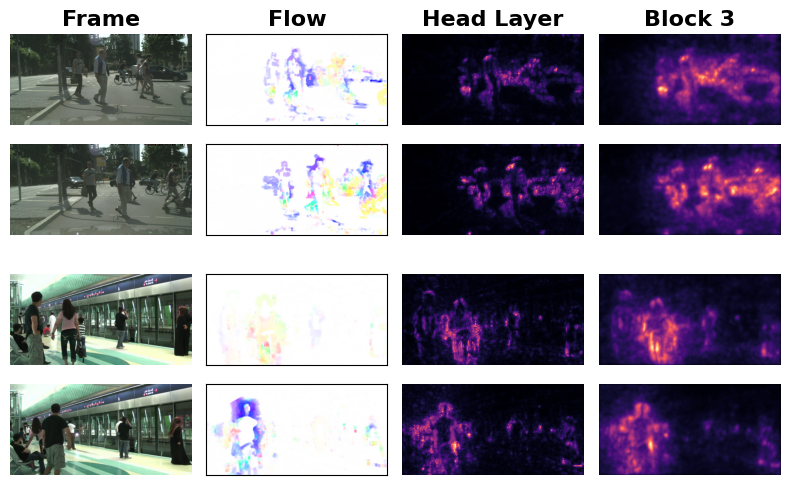

In [15]:
vidnames = ["0175", "26_cblDl5vCZnw"]

frame_nums = [1, 10]
# Size - num_vids*2 x 6 (RGB + Flow map + layerwise fluct + layerwise scatter)
fig, axs = plt.subplots(len(vidnames)*len(frame_nums)+1, 4, figsize=(8, 5), gridspec_kw={'height_ratios': [1, 1, 0.1, 1, 1]}, tight_layout=True)
# put space between two videos

for vid_idx, vidname in enumerate(vidnames):

    if vid_idx == 0:
        row_idx = vid_idx*len(frame_nums)
    else:
        row_idx = vid_idx*len(frame_nums) + 1 #(gap row)
    
    flow_inference_results = nerv_per_vid_optical_flow_dict[vidname]["inference_results"]
      
    axs[row_idx][0].axis('off')
    axs[row_idx+1][0].axis('off')
    
    for iter_idx, framenum in enumerate(frame_nums):
        
        # Get RGB image and HSV flow for current frame
        rgb_img = read_image(flow_paths[vidname][str(framenum)]["gt_img"])
        rgb_flow = np.load(flow_paths[vidname][str(framenum)]["rgb_flow"]) / 255.0
        
        rgb_flow = torch.from_numpy(rgb_flow).permute(2, 0, 1).float()
        if vidname in vipseg_vids:
            rgb_img = transforms.CenterCrop((640, 1280))(rgb_img)
            rgb_flow = transforms.CenterCrop((640, 1280))(rgb_flow)
        
        # Plot rgb_img
        axs[row_idx+iter_idx][0].imshow(rgb_img.permute(1, 2, 0).numpy())
        
        row_num = row_idx+iter_idx
        
        axs[row_num][1], axs[row_num][2], axs[row_num][3] \
            = plot_flow_and_fluctuation_maps(axs[row_num][1], axs[row_num][2], axs[row_num][3], flow_inference_results, framenum, rgb_flow)
    
    axs[0][0].set_title("Frame", fontsize=16, fontweight="bold")
    axs[0][1].set_title("Flow", fontsize=16, fontweight="bold")
    axs[0][2].set_title("Head Layer", fontsize=16, fontweight="bold")
    axs[0][3].set_title("Block 3", fontsize=16, fontweight="bold")

# Remove gap row
for ax in axs[2]:
    ax.axis('off')

In [17]:
# Save figure

os.makedirs('outputs/C/', exist_ok=True)
fig.savefig('outputs/C/4.3-optical_flow.pdf', bbox_inches="tight", pad_inches=0)